In [1]:
import rebound
import heyoka as hy
from tqdm import tqdm
from celmech import Poincare, PoincareHamiltonian
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import symengine as se
import time

In [2]:
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap, eta, L):
    P = (kap**2 + eta**2) / 2
    x = P / L
    return np.sqrt(x * (2 - x))

In [3]:
#heyoka integration

def hk_integrate(pham):
    #H_num = pham.H.subs(dict(pham.H_params))
    H_se = se.sympify(pham.H)
    clean_params_se = {se.sympify(k): v for k, v in dict(pham.H_params).items()
                   if not (hasattr(v, '__float__') and np.isnan(float(v)))}
    H_num = H_se.subs(clean_params_se)
    nan_symbols = {s: 0 for s in H_num.free_symbols 
               if str(s) not in {'Lambda1', 'Lambda2', 'eta1', 'eta2', 
                                  'kappa1', 'kappa2', 'lambda1', 'lambda2',
                                  'rho1', 'rho2', 'sigma1', 'sigma2'}}
    H_num = H_num.subs(nan_symbols)

    
    rho1,rho2,sigma1,sigma2 = se.symbols('rho1 rho2 sigma1 sigma2')
    sym_map = {s: 0 for s in H_num.free_symbols if str(s) in ('rho1', 'rho2', 'sigma1', 'sigma2')}
    H_planar = H_num.subs(sym_map)
    #H_planar = H_num.subs({rho1: 0, rho2: 0, sigma1: 0, sigma2: 0})
    H_planar = se.sympify(H_planar)
    print(sorted(str(s) for s in H_planar.free_symbols))

    lam1,lam2 = se.symbols('lambda1 lambda2')
    Lam1,Lam2 = se.symbols('Lambda1 Lambda2')
    eta1,eta2 = se.symbols('eta1 eta2')
    kap1, kap2 = se.symbols('kappa1 kappa2')

    print('*** Differentiating  ***')

    sym_dict = {str(s): s for s in H_planar.free_symbols}
    lam1 = sym_dict['lambda1']
    lam2 = sym_dict['lambda2']
    Lam1 = sym_dict['Lambda1']
    Lam2 = sym_dict['Lambda2']
    eta1 = sym_dict['eta1']
    eta2 = sym_dict['eta2']
    kap1 = sym_dict['kappa1']
    kap2 = sym_dict['kappa2']

    dLam1_dt = -se.diff(H_planar, lam1)
    dLam2_dt = -se.diff(H_planar, lam2)
    dlam1_dt =  se.diff(H_planar, Lam1)
    dlam2_dt =  se.diff(H_planar, Lam2)

    deta1_dt  = se.diff(H_planar, kap1)
    dkap1_dt  =  -se.diff(H_planar, eta1)
    deta2_dt  = se.diff(H_planar, kap2)
    dkap2_dt  =  -se.diff(H_planar, eta2)

    derivs = [dlam1_dt, dLam1_dt, dlam2_dt, dLam2_dt, deta1_dt, dkap1_dt, deta2_dt, dkap2_dt]

    vars_list = [lam1, Lam1, lam2, Lam2, eta1, kap1, eta2, kap2]
    func = se.Lambdify(vars_list,derivs)

    ast = pham.state.particles[1]
    jup = pham.state.particles[2]

    initial_conditions = [ast.l, ast.Lambda, jup.l, jup.Lambda,ast.eta, ast.kappa, jup.eta, jup.kappa]
    derivs_at_0 = func(*initial_conditions)

    derivs_at_0 = func(*initial_conditions)

    lam1_hy, Lam1_hy, lam2_hy, Lam2_hy, eta1_hy, kap1_hy, eta2_hy, kap2_hy = hy.make_vars('lam1_hy', 'Lam1_hy', 'lam2_hy', 'Lam2_hy', 'eta1_hy', 'kap1_hy', 'eta2_hy', 'kap2_hy')

    eqs_hy = [hy.from_sympy(sp.sympify(eq), {sp.Symbol('lambda1'): lam1_hy, 
                                          sp.Symbol('Lambda1'): Lam1_hy,
                                          sp.Symbol('lambda2'): lam2_hy, 
                                          sp.Symbol('Lambda2'): Lam2_hy,
                                          sp.Symbol('eta1'): eta1_hy, 
                                          sp.Symbol('kappa1'): kap1_hy,
                                          sp.Symbol('eta2'): eta2_hy, 
                                          sp.Symbol('kappa2'): kap2_hy})
           for eq in derivs]

    ta = hy.taylor_adaptive(sys=[(lam1_hy, eqs_hy[0]),(Lam1_hy, eqs_hy[1]),(lam2_hy, eqs_hy[2]),(Lam2_hy, eqs_hy[3]),(eta1_hy,  eqs_hy[4]),(kap1_hy,  eqs_hy[5]),(eta2_hy,  eqs_hy[6]),(kap2_hy,  eqs_hy[7])],
    state=initial_conditions,
    high_accuracy= True,
    time=0.0,
    tol=1e-22)


    times = np.linspace(0,16e3*np.pi*2,int(1e3))*2*np.pi
    e_ast = np.zeros(len(times))

    start = time.perf_counter()
    print('*** Starting Simulation ***')
    for i in tqdm(range(len(times))):
        ta.propagate_until(times[i])
        L, eta, kap = ta.state[1], ta.state[4], ta.state[5]
        e_ast[i] = get_ecc(kap, eta, L)
        
    end = time.perf_counter()
        
    print('*** Simulation Complete ***')

    print('Time elapsed  = ' + str(end-start) + ' seconds')

    return times, e_ast


['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 110626.79it/s]

*** Simulation Complete ***
Time elapsed  = 0.012252428000010696 seconds


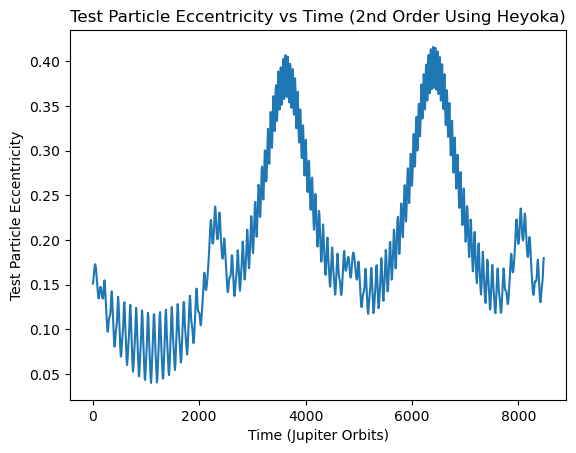

In [15]:
#testing with the wisdom 3:1 resonance textbook example page 461
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2,indexIn=1, indexOut=2, max_order=2) #3:1 MMR


times, e_ast = hk_integrate(pham)
plt.plot(times/(2*np.pi)/11.86,e_ast)
plt.ylabel('Test Particle Eccentricity')
plt.title('Test Particle Eccentricity vs Time (2nd Order Using Heyoka)')
plt.xlabel("Time (Jupiter Orbits)")
plt.show()

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:03<00:00, 286.21it/s]


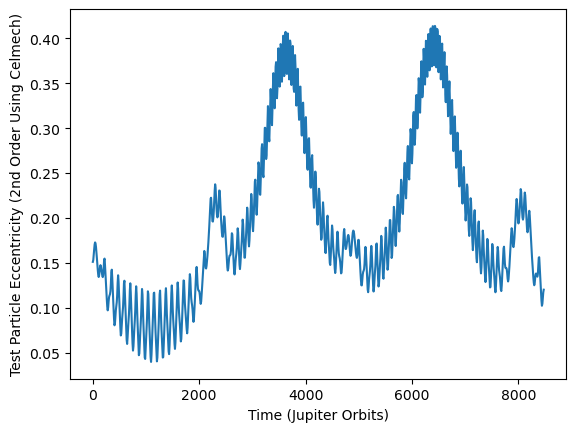

In [12]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

times = np.linspace(0,16e3*np.pi*2,int(1e3))*2*np.pi
e_ast = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham.add_MMR_terms(p=3,q=2,indexIn=1, indexOut=2, max_order=2) #3:1 MMR

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    e_ast[i] = pham.state.particles[1].e

plt.plot(times/(2*np.pi)/11.86,e_ast)
plt.ylabel('Test Particle Eccentricity (2nd Order Using Celmech)')
plt.xlabel("Time (Jupiter Orbits)")
plt.show()

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:42<00:00,  9.76it/s]


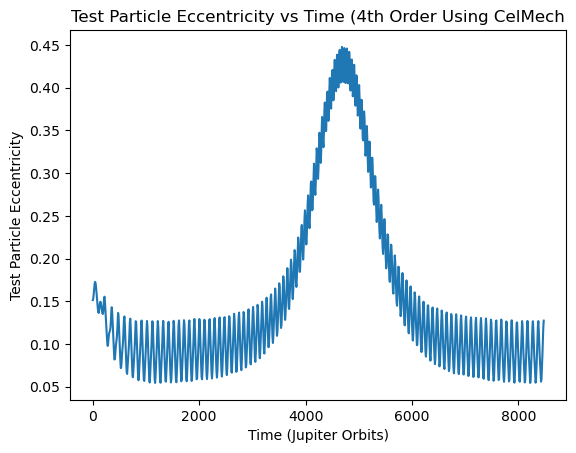

In [50]:
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

times = np.linspace(0,16e3*np.pi*2,int(1e3))*2*np.pi
e_ast = np.zeros(len(times))

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=2,indexIn=1, indexOut=2, max_order=4) #3:1 MMR

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    e_ast[i] = pham.state.particles[1].e

plt.plot(times/(2*np.pi)/11.86,e_ast)
plt.title('Test Particle Eccentricity vs Time (4th Order Using CelMech')
plt.ylabel('Test Particle Eccentricity')
plt.xlabel("Time (Jupiter Orbits)")
plt.show()

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
*** Starting Simulation ***


100%|███████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 629.21it/s]


*** Simulation Complete ***
Time elapsed  = 1.6016422079997028 seconds


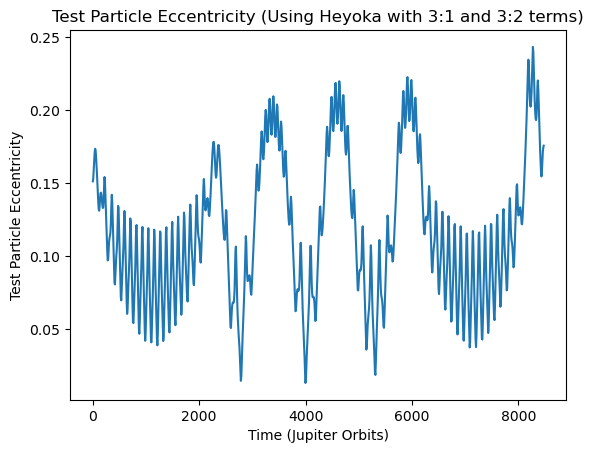

In [4]:
#testing with the wisdom 3:1 resonance textbook example page 461
sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=1e-10,a=2.502,e=0.15,inc = 0, Omega = 0,l = 0, pomega=0,hash="test particle")
sim.add(m=m_jup,a=5.2,e=0.048,inc = 0,Omega = 0,l = np.pi,pomega=0,hash="Jupiter")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn=1, indexOut=2, max_order=4)
pham.add_MMR_terms(p=3,q=2,indexIn=1, indexOut=2, max_order=2) #3:1 MMR
pham.add_MMR_terms(p=3,q=1,indexIn=1, indexOut=2, max_order=2)

times, e_ast = hk_integrate(pham)
plt.plot(times/(2*np.pi)/11.86,e_ast)
plt.title('Test Particle Eccentricity (Using Heyoka with 3:1 and 3:2 terms)')
plt.ylabel('Test Particle Eccentricity')
plt.xlabel("Time (Jupiter Orbits)")
plt.show() 